## TODO:
1. rename the columns
2. group the data by the time of the day 
4. find the average consumption

In [ ]:
import polars as pl
import pandas as pd
import numpy as np
import pyarrow
import seaborn as sns
import matplotlib.pyplot as plt

### import seaborn as sns

In [ ]:
plt.style.use('ggplot')

In [ ]:
def edit_column_names(df):
    df=df.rename(lambda col: col.replace('.energy_consumption',''))
    for column in df.columns:
        print (f'{column}, {df[column].dtype}')
    return df

In [ ]:
# checking distribution and relationships
def displaying_distribution(df, column_1, ax, f):
    sns.set_theme(style="ticks")
    sns.despine(f)
    sns.histplot(data=df, x="Hours", y=column_1, ax=ax, bins=50)
    ax.set(xlabel="Hours", ylabel=column_1, title=f'{column_1} Distribution in Hours', xticks=list(range(1,25)))

In [ ]:
def visualize_distribution(d):
    n_cols=len([n for n in d.dtypes if n ==pl.Float64]) -1
    fig, ax=plt.subplots(n_cols, 1, figsize=(10, 7 * n_cols) )
    indx=0
    for i in d.columns:
        if (d[i].dtype==pl.Float64 and i != 'units_represented'):
            displaying_distribution(d, i, ax[indx], fig)
            indx+=1
    plt.show()

In [ ]:
%%time
data=( 
    pl.read_csv('load_profile_data_mobile_home.csv', ignore_errors=True)
    .pipe(edit_column_names).with_columns(
        pl.col('timestamp').str.to_datetime("%Y-%m-%d %H:%M:%S")).with_columns(
        pl.col('timestamp').dt.hour().alias('Hours'))
)

In [ ]:
visualize_distribution(data)

In [ ]:
data.head(10)

In [ ]:
# checking missing values within the data
missing_values=data.null_count()
missing_values
# good there is no missing values

### Grouping by Hours of the day and getting the average for each stat per hour

In [ ]:
import polars.selectors as cs
grouped_average=data.group_by(pl.col('Hours')).agg(cs.float().mean()).sort(pl.col('Hours'))
# visualize_distribution(grouped_average)

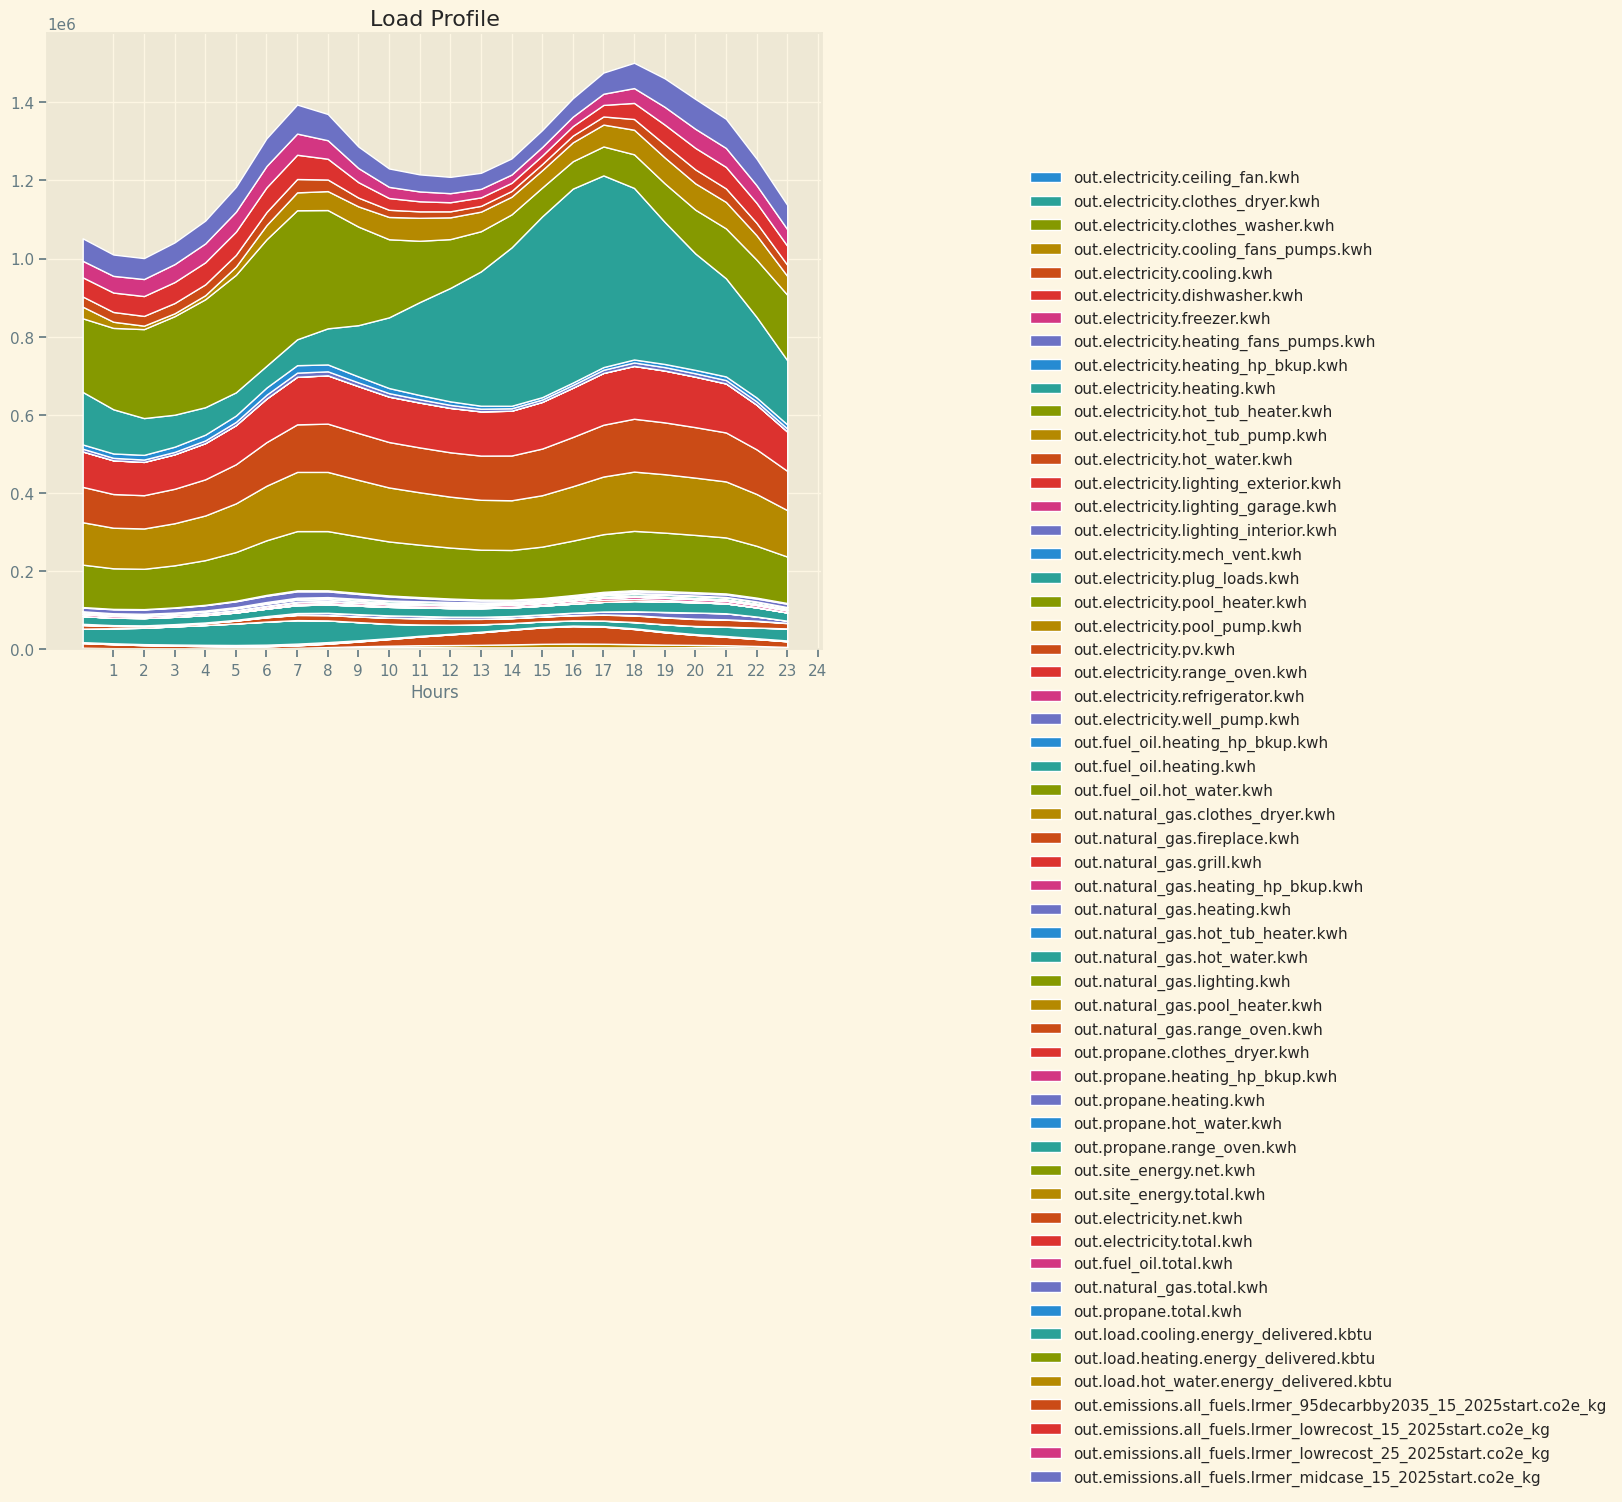

In [37]:
# plotting the average of ALl
plt.style.use('Solarize_Light2')
Labels=[n for n in grouped_average.columns if n not in['Hours','units_represented']]
usage=list(grouped_average.select(pl.all().exclude('Hours', 'units_represented')))

fig, ax=plt.subplots(1,1,figsize=(10,8))
ax.stackplot(grouped_average['Hours'], usage, labels=Labels)
ax.legend(loc='upper left', bbox_to_anchor=(1.25,0.8), frameon=False)
ax.set_xticks(list(range(1,25)))
ax.set_xlabel('Hours')
ax.set_title('Load Profile')
plt.show()